(100000, 29)
Placed Students: 54459
(43567, 26)
(10892, 26)

===== Linear Regression =====
MAE : 0.798
RMSE: 0.999
R2 Score: 0.606

===== Random Forest =====
MAE : 0.816
RMSE: 1.022
R2 Score: 0.588

===== XGBoost =====
MAE : 0.806
RMSE: 1.009
R2 Score: 0.598
                    Feature  Importance
2                      cgpa    0.304650
8        coding_skill_score    0.255387
5         internships_count    0.253919
23             resume_score    0.010075
25        recruitment_score    0.010048
24      employability_score    0.009558
16    attendance_percentage    0.009507
18    extracurricular_score    0.009256
19         leadership_score    0.009141
9            aptitude_score    0.009136
15     mock_interview_score    0.009039
11  logical_reasoning_score    0.008961
14     linkedin_connections    0.008839
21              sleep_hours    0.008833
13             github_repos    0.008767


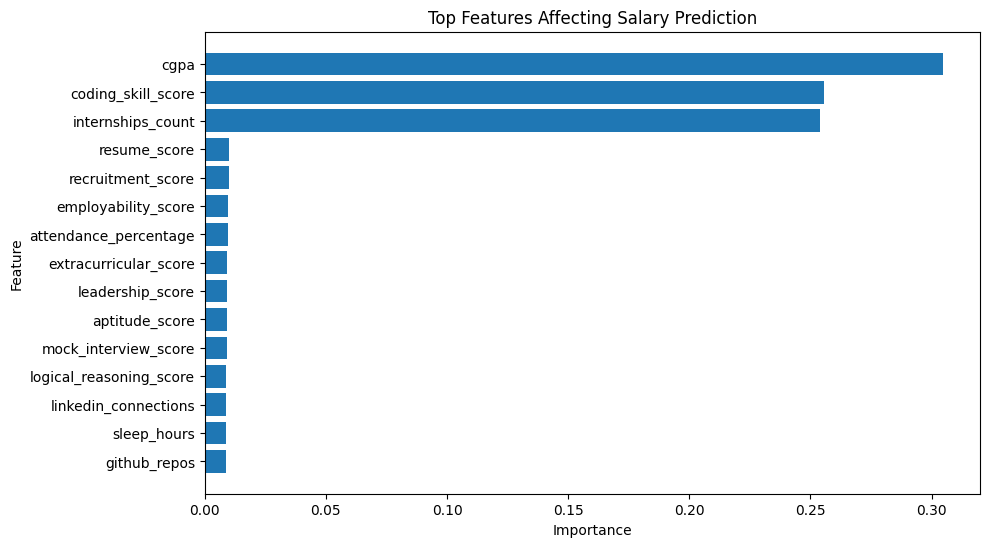

salary_package_lpa      1.000000
cgpa                    0.498746
coding_skill_score      0.455421
internships_count       0.391642
recruitment_score       0.356348
github_repos            0.002570
mock_interview_score   -0.003978
Name: salary_package_lpa, dtype: float64

===== MODEL COMPARISON =====
               Model  R2 Score       MAE      RMSE
0  Linear Regression  0.605879  0.798332  0.999210
2            XGBoost  0.597749  0.806459  1.009463
1      Random Forest  0.587839  0.816325  1.021823

Final Deployed Model: XGBoost
Reason: Better capability to capture complex recruitment patterns and future scalability.
salary_model.pkl saved successfully


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("student_placement_prediction_feature_engineered.csv")

print(df.shape)
df.head()

placed_df = df[df["placement_status"] == "Placed"].copy()

print("Placed Students:", placed_df.shape[0])

X = placed_df.drop(columns=[
    "student_id",
    "placement_status",
    "salary_package_lpa"
])

y = placed_df["salary_package_lpa"]

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n===== {name} =====")
    print("MAE :", round(mae, 3))
    print("RMSE:", round(rmse, 3))
    print("R2 Score:", round(r2, 3))

evaluate_model(
    "Linear Regression",
    y_test,
    pred_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    pred_xgb
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Affecting Salary Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()


salary_features = [
    "cgpa",
    "coding_skill_score",
    "internships_count",
    "recruitment_score",
    "mock_interview_score",
    "github_repos",
    "salary_package_lpa"
]

print(
    placed_df[salary_features]
    .corr()["salary_package_lpa"]
    .sort_values(ascending=False)
)

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb)
    ],
    "RMSE": [
        mean_squared_error(y_test, pred_lr) ** 0.5,
        mean_squared_error(y_test, pred_rf) ** 0.5,
        mean_squared_error(y_test, pred_xgb) ** 0.5
    ]
})

print("\n===== MODEL COMPARISON =====")
print(results.sort_values(
    by="R2 Score",
    ascending=False
))

print("\nFinal Deployed Model: XGBoost")
print("Reason: Better capability to capture complex recruitment patterns and future scalability.")

import joblib

joblib.dump(
    xgb,
    "salary_model.pkl"
)

print(
    "salary_model.pkl saved successfully"
)